In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

Real_folder = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\real"

Fake_folder = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\fake"

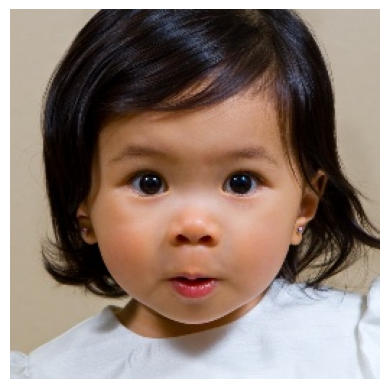

In [2]:
image_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\real\00003.jpg"  # Replace with your actual file path
img = Image.open(image_path)

# 2. Display the image
plt.imshow(img)
plt.axis("off")  # Removes the pixel coordinates/grid lines on the axes
plt.show()

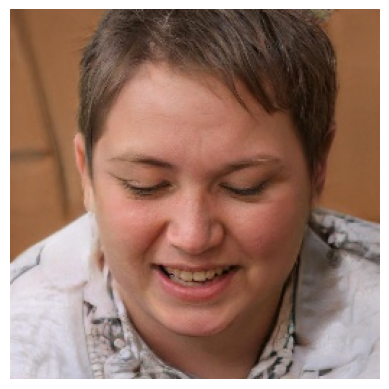

In [3]:
image_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\fake\0BYS14GRLS.jpg"  # Replace with your actual file path
img = Image.open(image_path)

# 2. Display the image
plt.imshow(img)
plt.axis("off")  
plt.show()

In [4]:
real_files = [
    f for f in os.listdir(Real_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

fake_files = [
    f for f in os.listdir(Fake_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of real images:", len(real_files))
print("Number of fake images:", len(fake_files))

print("\nFirst 5 real files:")
print(real_files[:5])

print("\nFirst 5 fake files:")
print(fake_files[:5])

Number of real images: 3500
Number of fake images: 3500

First 5 real files:
['00000.jpg', '00003.jpg', '00009.jpg', '00030.jpg', '00035.jpg']

First 5 fake files:
['002KDWZBHU.jpg', '009X14ED19.jpg', '00GYML2PNL.jpg', '017VGJOA5T.jpg', '019MPFQ50W.jpg']


In [5]:
# Check dimensions and color channels

real_img = Image.open(os.path.join(Real_folder, real_files[0]))
fake_img = Image.open(os.path.join(Fake_folder, fake_files[0]))

print("Real image:")
print("Size:", real_img.size)
print("Mode:", real_img.mode)

print("\nFake image:")
print("Size:", fake_img.size)
print("Mode:", fake_img.mode)

Real image:
Size: (256, 256)
Mode: RGB

Fake image:
Size: (256, 256)
Mode: RGB


In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load one real and one fake image
real_path = os.path.join(Real_folder, real_files[0])
fake_path = os.path.join(Fake_folder, fake_files[0])

real_img = Image.open(real_path).convert("RGB")
fake_img = Image.open(fake_path).convert("RGB")

# Resize to Inception-v3 input size
real_resized = real_img.resize((342 , 342))
fake_resized = fake_img.resize((342, 342))

print("Original real:", real_img.size)
print("Resized real:", real_resized.size)

print("Original fake:", fake_img.size)
print("Resized fake:", fake_resized.size)

Original real: (256, 256)
Resized real: (342, 342)
Original fake: (256, 256)
Resized fake: (342, 342)


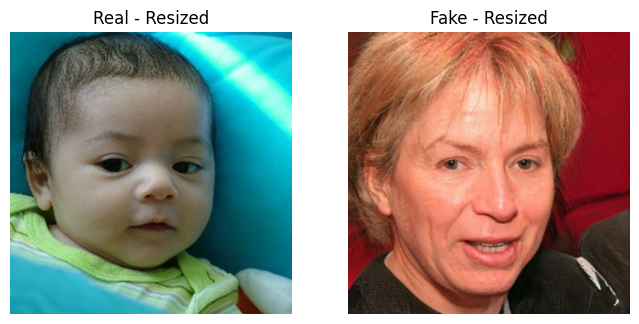

In [18]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(real_resized)
plt.title("Real - Resized")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(fake_resized)
plt.title("Fake - Resized")
plt.axis("off")

plt.show()

In [10]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu


In [1]:
import torch
from torchvision.models import inception_v3, Inception_V3_Weights

# Load the official ImageNet-pretrained Inception-v3 weights
weights = Inception_V3_Weights.DEFAULT

model = inception_v3(weights=weights)

# We are only extracting features, so use evaluation mode
model.eval()

# CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Model loaded successfully.")

Device: cpu
Model loaded successfully.


In [2]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# RVF10K training dataset
data_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train"

# Exact preprocessing for the pretrained Inception-v3 weights
preprocess = weights.transforms()

# Load images
dataset = ImageFolder(
    root=data_path,
    transform=preprocess
)

print("Number of images:", len(dataset))
print("Classes:", dataset.class_to_idx)

Number of images: 7000
Classes: {'fake': 0, 'real': 1}


In [3]:
batch_size = 32

data_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Batch size:", batch_size)
print("Number of batches:", len(data_loader))

Batch size: 32
Number of batches: 219


In [4]:
# Get one batch
images, labels = next(iter(data_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Move images to the same device as the model
images = images.to(device)

# Run one batch through Inception-v3
with torch.inference_mode():
    output = model(images)

print("Model output shape:", output.shape)

Image batch shape: torch.Size([32, 3, 299, 299])
Label batch shape: torch.Size([32])
Model output shape: torch.Size([32, 1000])


In [5]:
# Replace the final 1000-class classifier with an identity layer
model.fc = torch.nn.Identity()

# Run the same batch again
with torch.inference_mode():
    features = model(images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([32, 2048])
